# import 

In [ ]:
import numpy as np
import os
import json
import pandas as pd 
import matplotlib.pyplot as plt
import ast

def load_in_sleep_state_scoring(mouse):
    print('---------------------')
    print('searching for sleep state scoring')
    # determine organised data paths for the current mouse
    if mouse.split('_')[0].isdigit():
        org_dat_path = r"Z:\projects\sequence_squad\organised_data\animals\\"
        old_data = True
    else:
        org_dat_path = r"Z:\projects\sequence_squad\revision_data\organised_data\animals\\"
        old_data = False
    org_mouse_file = None
    for file in os.listdir(org_dat_path):
        if mouse.split('_')[0] in file:
            # if the implant = implant
            if mouse.split('_')[1] == file.split('_')[-1][-1]:
                print(f'1. mouse file found: \033[1m{file}\033[0m')
                org_mouse_file = os.path.join(org_dat_path,file)
    mouse_org_data_path = None
    for recording in os.listdir(org_mouse_file):
        if mouse.split('_')[-1] == recording.split('ing')[-1].split('_')[0]:
            print(f'2. recording found: \033[1m{recording}\033[0m')
            mouse_org_data_path = os.path.join(org_mouse_file,recording) + r'\\'

    # load in sleep scoring data 

    sleep_state_score_path = mouse_org_data_path + r"\ephys\LFP\\sleep_state_score\\"
    if not os.path.exists(sleep_state_score_path):
        sleep_state_score_path =  mouse_org_data_path + '/ephys/probeA/LFP/'

    if not os.path.exists(sleep_state_score_path):
        print(f"Sleep state score files not found for {mouse}.")
    else:
        nrem_start_ends = np.load(sleep_state_score_path + "nrem_start_ends.npy", allow_pickle=True)
        rem_start_ends = np.load(sleep_state_score_path + "rem_start_ends.npy", allow_pickle=True)
        print (f"\033[1mSuccess!\033[0m Loaded sleep state score files for mouse: {mouse}.")

    print('----------------------')
        
    return nrem_start_ends,rem_start_ends,mouse_org_data_path,old_data

##################################

def load_in_replay_data(mouse,old_data_bool):
    
    print('---------------------')
    print('searching for replay data')
    dat_path = r"Z:\projects\sequence_squad\ppseq_finalised_publication_data\expert\postsleep\\"
    # if old_data_bool:
    #     dat_path = r"Z:\projects\sequence_squad\organised_data\ppseq_data\finalised_output\striatum\paper_submission\post_sleep\\"
    # else:
    #     dat_path = ERROR_REPLACE_ME

    pp_path = 'SKIP'
    for file in os.listdir(dat_path):
        if mouse in file:
            print(f'file found: \033[1m{file}\033[0m')
            pp_path = os.path.join(dat_path,file)
    
    print(pp_path)
    if pp_path == 'SKIP':
        return None,'SKIP'
    replay_data_path = pp_path + r'\_final_analysis_output\\'

    params_file = pp_path + r'\trainingData\\' + 'params_' + mouse + '.json'
    with open(params_file, 'r') as file:
        params = json.load(file)
    time_spans = params['time_span']
    
    replay_events_df = pd.DataFrame({})
    start_offset = []
    for file in os.listdir(replay_data_path):
        if 'chunk' in file:
            print(file)

            chunk_number = int(file.split('_')[0][-1])

            start_offs = ([0]+list(np.cumsum(np.diff(time_spans))))[chunk_number-1]
            start_offset +=[start_offs]


            print(replay_data_path)

            df_load = pd.read_csv(replay_data_path + file + r'\filtered_replay_clusters_df.csv',index_col=0)
            df_load['chunk'] = [chunk_number]*len(df_load)
            
            df_load['chunk_time'] = [time_spans[chunk_number-1]]*len(df_load)
            fs_times_ephys_time = (df_load.first_spike_time.values - start_offs)
            df_load['first_spike_ephys_time'] = fs_times_ephys_time
            df_load["replay_abs_time"] = df_load['chunk_time'].values[0][0] + df_load["first_spike_ephys_time"] + df_load["event_length"]/2
            replay_events_df = pd.concat((replay_events_df,df_load),axis =0)
            replay_events_df.reset_index(drop = True)

    print (f"\033[1mSuccess!\033[0m Loaded replay data files for mouse: {mouse}.")
    print('---------------------')
    return replay_events_df, None


# main

In [162]:
# load in all replay times - start and and end times 
# load in all spindle start and end times 
# start and end times for SWRs 

# Bonus:
# linkage vs neuron consistency? seemed like there was an effect...quite cool maybe?  

269_1_3
---------------------
searching for sleep state scoring
1. mouse file found: EJT269_implant1
2. recording found: recording3_16-05-2023
Success! Loaded sleep state score files for mouse: 269_1_3.
----------------------
---------------------
searching for replay data
file found: 269_1_3_run_2806023_1335
Z:\projects\sequence_squad\ppseq_finalised_publication_data\expert\postsleep\\269_1_3_run_2806023_1335
chunk1_8000to9000
Z:\projects\sequence_squad\ppseq_finalised_publication_data\expert\postsleep\\269_1_3_run_2806023_1335\_final_analysis_output\\
chunk2_9000to10000
Z:\projects\sequence_squad\ppseq_finalised_publication_data\expert\postsleep\\269_1_3_run_2806023_1335\_final_analysis_output\\
chunk3_11500to12500
Z:\projects\sequence_squad\ppseq_finalised_publication_data\expert\postsleep\\269_1_3_run_2806023_1335\_final_analysis_output\\
Success! Loaded replay data files for mouse: 269_1_3.
---------------------
270_1_3
---------------------
searching for sleep state scoring
1. mo

Text(0, 0.5, 'Spindle vs baseline replay rate ratio')

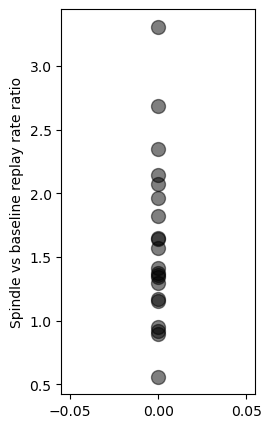

In [261]:
spindle_data_path = r"Z:\projects\sequence_squad\revision_data\emmett_revisions\oscillations\striatum_lfp\expert\\"

ratio_inSpindle_toOut = []
for mouse in os.listdir(spindle_data_path):
    print(mouse)
    # load spindle data 
    full_path = spindle_data_path + mouse + r'\analysis\\'
    spindle_events= np.load(full_path + 'spindle_events.npy', allow_pickle = True)
    unit_consistency_awake= np.load(full_path + 'unit_consistency_awake.npy', allow_pickle = True)
    
    ## load in sleep state scoring data
    nrem_start_ends,rem_start_ends,mouse_org_data_path,old_data_bool = load_in_sleep_state_scoring(mouse)
    replay_events_df,replay_exists_bool = load_in_replay_data(mouse,old_data_bool)
    replay_events_df= replay_events_df.reset_index()
    
    chunk_times = np.unique(replay_events_df.chunk_time.values)
        
    #### determine replay rate in vs outside of apindle events
    replay_start_times = []
    replay_end_times = []
    for i in range(len(replay_events_df)):
        chunk_cumulative_offset = [0] + list(np.cumsum([np.diff(item) for item in (np.unique(replay_events_df.chunk_time.values))]))
        chunk_offset = chunk_cumulative_offset[replay_events_df.chunk[i] - 1]
        replay_start_times += [(min(ast.literal_eval(replay_events_df.cluster_spike_times[i])) - chunk_offset) + replay_events_df.chunk_time[i][0]]
        replay_end_times += [(max(ast.literal_eval(replay_events_df.cluster_spike_times[i])) - chunk_offset) + replay_events_df.chunk_time[i][0]]

    spindle_starts = []
    spindle_ends = []
    for spin_event in spindle_events:
        spindle_starts += [spin_event['start_time']]
        spindle_ends += [spin_event['end_time']]

    # convert to np arrays
    replay_start_times = np.array(replay_start_times)
    spindle_starts = np.array(spindle_starts)
    replay_end_times = np.array(replay_end_times)
    spindle_ends = np.array(spindle_ends)

    ## bin time
    bin_width = 0.1  # 200 ms
    # Use the full time range covered by replays and spindles
    t_min = min(replay_start_times.min(), spindle_starts.min())
    t_max = max(replay_end_times.max(),   spindle_ends.max())
    bin_edges  = np.arange(t_min, t_max + bin_width, bin_width)
    bin_starts = bin_edges[:-1]
    bin_ends   = bin_edges[1:]
    bin_centres = (bin_starts + bin_ends) / 2

    #ignore any bins that are outside the replay chunks 
    chunk_times = np.unique(replay_events_df.chunk_time.values)
    # A bin is included if its centre falls inside ANY chunk
    in_chunk_bin = np.zeros(len(bin_centres), dtype=bool)
    for start, end in chunk_times:
        in_chunk_bin |= (bin_centres >= start) & (bin_centres <= end)


    # Count replay events per bin
    # A replay overlaps a bin if: replay_start < bin_end AND replay_end > bin_start
    replay_counts_per_bin = (
        (replay_start_times[:, None] < bin_ends[None, :]) &
        (replay_end_times[:, None]   > bin_starts[None, :])
    ).sum(axis=0)


    # Determine which bins overlap ANY spindle
    # A spindle overlaps a bin using the same overlap rule
    spindle_overlap_per_bin = (
        (spindle_starts[:, None] < bin_ends[None, :]) &
        (spindle_ends[:, None]   > bin_starts[None, :])
    ).any(axis=0)

    # Apply chunk restriction
    valid_bins = in_chunk_bin
    spindle_bins = spindle_overlap_per_bin & valid_bins
    non_spindle_bins = (~spindle_overlap_per_bin) & valid_bins

    # Split bins: spindle vs non-spindle
    replay_counts_in_spindle_bins = replay_counts_per_bin[spindle_bins]
    replay_counts_outside_spindle_bins = replay_counts_per_bin[non_spindle_bins]

    # get average per bin
    total_replay_bin_counts_in_spindles = replay_counts_in_spindle_bins.sum()
    total_replay_bin_counts_outside_spindles = replay_counts_outside_spindle_bins.sum()

    number_of_spindle_bins = spindle_overlap_per_bin.sum()
    number_of_non_spindle_bins = (~spindle_overlap_per_bin).sum()

    # normalise by bins
    replay_rate_in_spindles = (
        total_replay_bin_counts_in_spindles / number_of_spindle_bins
        if number_of_spindle_bins > 0 else np.nan
    )
    replay_rate_outside_spindles = (
        total_replay_bin_counts_outside_spindles / number_of_non_spindle_bins
        if number_of_non_spindle_bins > 0 else np.nan
    )

    ratio_inSpindle_toOut += [replay_rate_in_spindles / replay_rate_outside_spindles] 



fig, ax = plt.subplots(1, 1,figsize=(2.5, 5))
for item in ratio_inSpindle_toOut:
    ax.plot(item,'o', color = 'k', alpha = 0.5, markersize = 10)
ax.set_ylabel('Spindle vs baseline replay rate ratio')

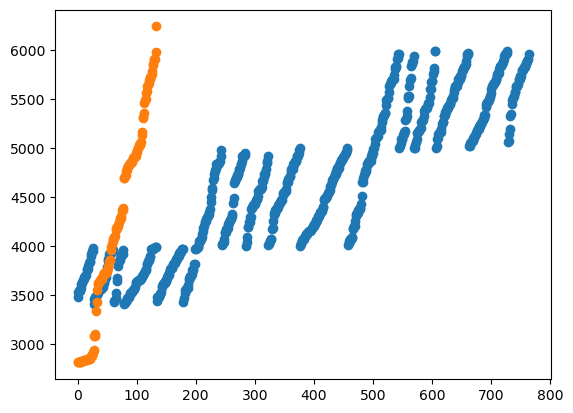

In [262]:
plt.plot(replay_start_times,'o')
plt.plot(spindle_starts,'o')

In [ ]:
spindle_bins

In [249]:
number_of_non_spindle_bins

np.int64(29711)

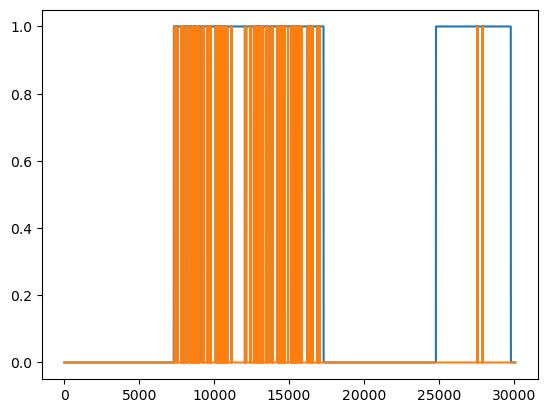

In [250]:
plt.plot(non_spindle_bins*1)
plt.plot(spindle_bins*1)

In [198]:
number_of_non_spindle_bins

np.int64(39407)

In [193]:
spindle_events

array([{'start_time': np.float64(8076.045768689993), 'end_time': np.float64(8076.715368689993), 'peak_magnitude': np.float64(1.2251576852378026), 'magnitude': np.float64(1180.3787056096592), 'average_magnitude': np.float64(0.9747140426173899)},
       {'start_time': np.float64(8080.908968689992), 'end_time': np.float64(8081.230968689993), 'peak_magnitude': np.float64(1.0125263168160947), 'magnitude': np.float64(343.38296814191176), 'average_magnitude': np.float64(0.9331058916899776)},
       {'start_time': np.float64(8103.252168689993), 'end_time': np.float64(8103.722968689993), 'peak_magnitude': np.float64(1.1492280746288037), 'magnitude': np.float64(748.1896915821006), 'average_magnitude': np.float64(0.9679038700932738)},
       {'start_time': np.float64(8124.918968689993), 'end_time': np.float64(8125.284968689993), 'peak_magnitude': np.float64(1.1303716717923113), 'magnitude': np.float64(688.5774092772486), 'average_magnitude': np.float64(0.9753221094578592)},
       {'start_time': 

In [179]:
### Replay onset vs spindle on/off times - essentially linkage distance for replay on and off 

# first spike times 

replay_start_times
spindle_starts
spindle_ends

array([ 6540.47568057,  6642.74008057,  6705.35688057,  6902.93528057,
        7859.85808057,  7974.95808057,  7992.49728057,  7996.11088057,
        8012.40288057,  8047.14568057,  8100.34848057,  8112.32648057,
        8114.23528057,  8122.16648057,  8126.24408057,  8133.94528057,
        8136.48048057,  8173.62728057,  8185.12848057,  8227.34928057,
        8230.71088057,  8263.42248057,  8266.62648057,  8267.57688057,
        8286.21808057,  8319.19448057,  8323.04608057,  8324.74128057,
        8326.22928057,  8326.92608057,  8341.81208057,  8386.21608057,
        8402.63568057,  8449.74288057,  8469.98728057,  8482.18488057,
        8486.13688057,  8492.34608057,  8492.94248057,  8496.34928057,
        8560.87288057,  8569.88088057,  8576.28048057,  8584.21008057,
        8610.09528057,  8626.12328057,  8652.52768057,  8676.41048057,
        8701.42888057,  8705.55088057,  8714.29968057,  8772.80048057,
        8950.70728057,  8965.58928057,  8966.59048057,  9025.83008057,
      

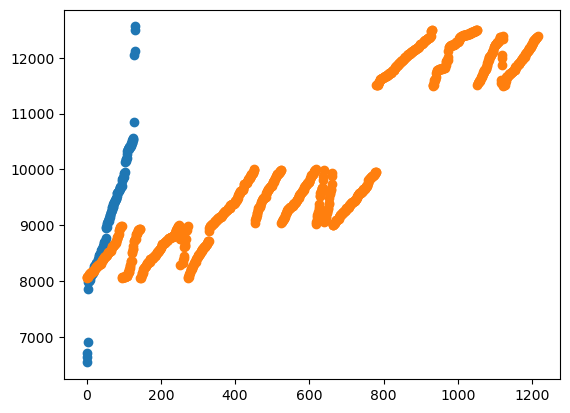

In [247]:
plt.plot(spindle_starts, 'o')
plt.plot(replay_start_times, 'o')

In [209]:
replay_start_times

array([ 8061.1888,  8062.6934,  8063.0295, ..., 14364.7739, 14366.8743,
       14391.853 ], shape=(1216,))

In [189]:
replay_start_times

array([ 8061.1888,  8062.6934,  8063.0295, ..., 14364.7739, 14366.8743,
       14391.853 ], shape=(1216,))

In [181]:
def define_spindle_linkage(spindle_events,replay_times):
    spindle_linkage_distance = []
    for event in replay_times:
        current_shortest_dist = 999999
        for spin_mid in spindle_events:
            distance = abs(spin_mid - event)
            if distance < abs(current_shortest_dist):
                current_shortest_dist = (spin_mid - event)
        spindle_linkage_distance += [current_shortest_dist]
    return spindle_linkage_distance

(array([ 94., 102.,  76., 102.,  61.,   0.,   0.,   0.,  74., 707.]),
 array([-1939.39551943, -1731.90424943, -1524.41297943, -1316.92170943,
        -1109.43043943,  -901.93916943,  -694.44789943,  -486.95662943,
         -279.46535943,   -71.97408943,   135.51718057]),
 <BarContainer object of 10 artists>)

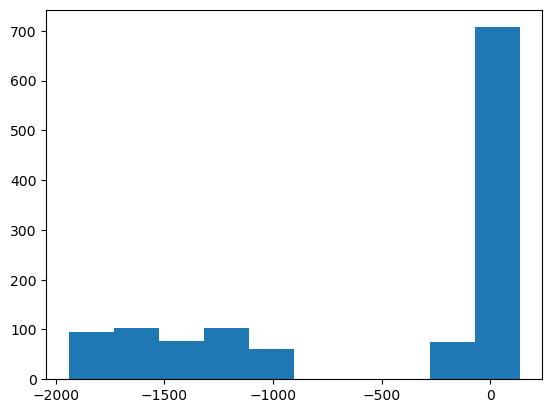

In [184]:
plt.hist(define_spindle_linkage(spindle_starts,replay_start_times))

In [91]:
replay_counts_in_spindle_bins



# =========================
# Final quantities you asked for
# =========================
total_replay_bin_counts_in_spindles = replay_counts_in_spindle_bins.sum()
total_replay_bin_counts_outside_spindles = replay_counts_outside_spindle_bins.sum()

number_of_spindle_bins = spindle_overlap_per_bin.sum()
number_of_non_spindle_bins = (~spindle_overlap_per_bin).sum()

# normalise by bins
replay_rate_in_spindles = (
    total_replay_bin_counts_in_spindles / number_of_spindle_bins
    if number_of_spindle_bins > 0 else np.nan
)
replay_rate_outside_spindles = (
    total_replay_bin_counts_outside_spindles / number_of_non_spindle_bins
    if number_of_non_spindle_bins > 0 else np.nan
)
# convert to rate per min 



In [92]:
replay_rate_outside_spindles

np.float64(0.32653159131978315)

np.float64(195.91895479186988)

np.float64(260.3644646924829)

In [ ]:
import numpy as np

# =========================
# Inputs
# =========================
# replay_start_times : list/array of replay start times (seconds)
# replay_end_times   : list/array of replay end times   (seconds)
# spindle_starts     : list/array of spindle start times
# spindle_ends       : list/array of spindle end times
# chunk_times        : array-like of [start, end] epochs to include

replay_starts  = np.asarray(replay_start_times)
replay_ends    = np.asarray(replay_end_times)
spindle_starts = np.asarray(spindle_starts)
spindle_ends   = np.asarray(spindle_ends)
chunk_times    = np.asarray(chunk_times, dtype=float)

bin_width = 0.05  # 50 ms


# =========================
# Define time bins
# =========================
t_min = min(replay_starts.min(), spindle_starts.min())
t_max = max(replay_ends.max(),   spindle_ends.max())

bin_edges  = np.arange(t_min, t_max + bin_width, bin_width)
bin_starts = bin_edges[:-1]
bin_ends   = bin_edges[1:]
bin_centres = (bin_starts + bin_ends) / 2


# =========================
# Restrict bins to chunks
# =========================
# A bin is included if its centre falls inside ANY chunk
in_chunk_bin = np.zeros(len(bin_centres), dtype=bool)

for start, end in chunk_times:
    in_chunk_bin |= (bin_centres >= start) & (bin_centres <= end)


# =========================
# Count replay events per bin
# =========================
# Replay overlaps a bin if:
#   replay_start < bin_end AND replay_end > bin_start
replay_counts_per_bin = (
    (replay_starts[:, None] < bin_ends[None, :]) &
    (replay_ends[:, None]   > bin_starts[None, :])
).sum(axis=0)


# =========================
# Determine which bins overlap ANY spindle
# =========================
spindle_overlap_per_bin = (
    (spindle_starts[:, None] < bin_ends[None, :]) &
    (spindle_ends[:, None]   > bin_starts[None, :])
).any(axis=0)


# =========================
# Apply chunk restriction
# =========================
valid_bins = in_chunk_bin

spindle_bins = spindle_overlap_per_bin & valid_bins
non_spindle_bins = (~spindle_overlap_per_bin) & valid_bins


# =========================
# Final quantities of interest
# =========================
total_replay_bin_counts_in_spindles = replay_counts_per_bin[spindle_bins].sum()
total_replay_bin_counts_outside_spindles = replay_counts_per_bin[non_spindle_bins].sum()

number_of_spindle_bins = spindle_bins.sum()
number_of_non_spindle_bins = non_spindle_bins.sum()


# =========================
# Optional: normalised rates
# =========================
replay_rate_in_spindles = (
    total_replay_bin_counts_in_spindles / number_of_spindle_bins
    if number_of_spindle_bins > 0 else np.nan
)

replay_rate_outside_spindles = (
    total_replay_bin_counts_outside_spindles / number_of_non_spindle_bins
    if number_of_non_spindle_bins > 0 else np.nan
)


array([list([8700, 9300]), list([10000, 11600]), list([11900, 12500])],
      dtype=object)

In [29]:
bin_edges

array([ 8700.0014    ,  8700.0514    ,  8700.1014    , ...,
       14699.50139991, 14699.55139991, 14699.60139991], shape=(119993,))

In [28]:
spindle_overlap_per_bin

array([ True,  True,  True, ..., False, False, False], shape=(126822,))

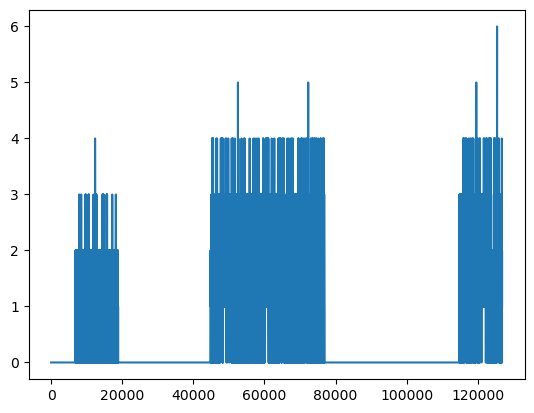

In [27]:
plt.plot(replay_counts_per_bin)

In [22]:
replay_rate_in_spindles

np.float64(0.4347275031685678)

In [21]:
replay_rate_outside_spindles

np.float64(0.4865781993548593)

In [ ]:
# bin replay into 100ms or maybe 50ms time bins, calculate rate
#take bins which contain a spindle vs bins that dont?  

In [ ]:
    # pull out replay times (first spike and mid points)
    replay_fs_times = []
    replay_mid_times  = []
    for index, chunktime in enumerate(replay_events_df.chunk_time):
        chunk_cumulative_offset = cumulative_chunk_start_times[replay_events_df.chunk[index] - 1]
        #relative replay time within all chunks
        rel_cumchunks_time = (replay_events_df.first_spike_time[index] - chunk_cumulative_offset)
        # replay time in ephys time
        replay_time_fs_ephys = rel_cumchunks_time + chunktime[0]
        replay_fs_times += [replay_time_fs_ephys]
        # half length of replay
        half_length = (replay_events_df.last_spike_time[index] - replay_events_df.first_spike_time[index])/2 
        replay_mid_times += [replay_time_fs_ephys + half_length]

In [ ]:
####################################### Spindle Linkage Totals #################################################

# proportion of replay events that are linked to spindles (in rem and nrem also)
spindle_start_times = np.array([item['start_time'] for item in spindle_events]) - sleep_period_ephys_start_time

linked_events = 0
nrem_events = 0
linked_nrem_events = 0
rem_events = 0
linked_rem_events = 0
for event in replay_fs_times:
    window = (event - 1.5, event + 1.5)
    mask = (spindle_start_times > window[0]) * (spindle_start_times < window[1])
    if np.sum(mask) > 0:
        linked_events += 1
        

prop_spin_linked_total = linked_events / len(replay_fs_times)
if nrem_events > 0 :
    prop_spin_linked_nrem = linked_nrem_events / nrem_events
else:
    prop_spin_linked_nrem = 0
if rem_events > 0:
    prop_spin_linked_rem = linked_rem_events / rem_events
else:
    prop_spin_linked_rem = 0

print(f'proportion of replay events that are linked to spindles (total) {prop_spin_linked_total}')
print(f'proportion of replay events that are linked to spindles (nrem) {prop_spin_linked_nrem}')
print(f'proportion of replay events that are linked to spindles (rem) {prop_spin_linked_rem}')

In [26]:
for spindle in spindle_events:
    spindle

{'start_time': np.float64(6540.054880572929),
 'end_time': np.float64(6540.4756805729285),
 'peak_magnitude': np.float64(3.641010354552333),
 'magnitude': np.float64(1435.5199843744574),
 'average_magnitude': np.float64(2.372760304751169)}

In [24]:
replay_events_df

,Unnamed: 0.1,Unnamed: 0,cluster_seq_type,num_spikes,num_neurons,first_spike_time,event_length,last_spike_time,cluster_spike_times,cluster_neurons,spike_plotting_order,coactive_cluster_group,ordering_classification,rem_events,nrem_events,chunk,chunk_time,first_spike_ephys_time,replay_abs_time
0,0,12,1,6,61.1113,61.0187,0.0926,61.1113,"[61.0187, 61.1113, 61.0424, 61.0223, 61.0485, ...","[48.0, 48.0, 57.0, 68.0, 68.0, 68.0]",[22. 22. 30. 31. 31. 31.],8.0,fragmented,0,0,1,"[8000, 9000]",61.0187,8061.06500
1,1,13,1,196,62.9629,61.1881,1.7748,62.9629,"[61.2526, 61.7073, 61.9003, 62.3762, 61.7763, ...","[7.0, 12.0, 12.0, 12.0, 18.0, 19.0, 19.0, 19.0...",[14. 28. 28. 28. 19. 26. 26. 26. 26. 26. 26. 6...,8.0,fragmented,0,0,1,"[8000, 9000]",61.1881,8062.07550
2,2,14,1,63,63.5461,63.0295,0.5166,63.5461,"[63.289, 63.2952, 63.3044, 63.3245, 63.3356, 6...","[12.0, 35.0, 35.0, 35.0, 35.0, 35.0, 36.0, 36....",[28. 27. 27. 27. 27. 27. 55. 55. 55. 55. 55. 5...,8.0,fragmented,0,0,1,"[8000, 9000]",63.0295,8063.28780
3,3,15,1,7,63.9180,63.8214,0.0966,63.9180,"[63.8508, 63.843, 63.8346, 63.8214, 63.8938, 6...","[36.0, 48.0, 67.0, 68.0, 68.0, 73.0, 73.0]",[55. 22. 21. 31. 31. 45. 45.],9.0,fragmented,0,0,1,"[8000, 9000]",63.8214,8063.86970
4,4,16,1,25,65.9497,65.7509,0.1988,65.9497,"[65.9162, 65.8324, 65.7605, 65.7782, 65.784, 6...","[39.0, 43.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48....",[65. 24. 22. 22. 22. 22. 22. 22. 22. 30. 30. 3...,10.0,sequential,0,0,1,"[8000, 9000]",65.7509,8065.85030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482,482,482,6,68,2861.3879,2860.1727,1.2152,2861.3879,"[2860.1727, 2860.2063, 2860.2267, 2860.2759, 2...","[28.0, 28.0, 28.0, 36.0, 36.0, 36.0, 36.0, 36....",[49. 49. 49. 55. 55. 55. 55. 55. 35. 41. 22. 2...,89.0,sequential,0,0,3,"[11500, 12500]",860.1727,12360.78030
483,483,483,6,38,2865.7507,2864.6039,1.1468,2865.7507,"[2865.2459, 2865.2817, 2865.3449, 2865.206, 28...","[11.0, 11.0, 11.0, 19.0, 36.0, 44.0, 44.0, 44....",[44. 44. 44. 26. 55. 35. 35. 35. 35. 41. 41. 4...,90.0,sequential,0,0,3,"[11500, 12500]",864.6039,12365.17730
484,484,484,6,46,2868.0581,2866.7684,1.2897,2868.0581,"[2866.8743, 2866.8996, 2867.1103, 2866.8157, 2...","[11.0, 11.0, 11.0, 28.0, 28.0, 28.0, 28.0, 36....",[44. 44. 44. 49. 49. 49. 49. 55. 55. 55. 41. 2...,91.0,fragmented,0,0,3,"[11500, 12500]",866.7684,12367.41325
485,485,485,6,8,2891.8686,2891.8530,0.0156,2891.8686,"[2891.8591, 2891.8549, 2891.8557, 2891.853, 28...","[35.0, 48.0, 48.0, 49.0, 49.0, 50.0, 51.0, 53.0]",[27. 22. 22. 33. 33. 38. 39. 94.],135.0,fragmented,1,0,3,"[11500, 12500]",891.8530,12391.86080


In [ ]:
replay_events_df

In [ ]:
# replay rate inside spindle events vs outside


In [21]:
all_mice = ['seq006_1_1',
 'seq006_1_3',
 'seq006_1_4',
 'seq006_1_5',
 'seq006_1_6',
 'seq006_1_8',
 'seq006_1_11',
 'seq007_1_1',
 'seq007_1_2',
 'seq007_1_3',
 'seq007_1_4',
 'seq008_1_3',
 'seq120_1_3',
 'seq120_1_4',
 'seq120_1_6',
 'seq120_1_7',
 'seq120_1_8']

ripples_path = r"Z:\projects\sequence_squad\revision_data\emmett_revisions\oscillations\hippocampus_lfp\processed_ripples\\"

for current_mouse in all_mice:
    print(current_mouse)
    
    for mouse_file in os.listdir(ripples_path):
        
        # 1 RIPPLES #####
        if mouse_file.split('.csv')[0] == current_mouse:
            # import ripples for mouse
            print('ripples found')
            ripples_df = pd.read_csv(ripples_path + mouse_file)
        # import ripple info
        

    # REPLAY ########### import replay info for mouse
    replay_path = r'Z:\projects\sequence_squad\ppseq_finalised_publication_data\dual_str_hpc\striatum\postsleep\\' 
    
    replay_events_df,chunk_spans= load_in_replay_data(current_mouse,replay_path)
    

    break


seq006_1_1
ripples found
---------------------
searching for replay data
seq006_1_3
ripples found
---------------------
searching for replay data
seq006_1_4
ripples found
---------------------
searching for replay data
seq006_1_5
ripples found
---------------------
searching for replay data
seq006_1_6
ripples found
---------------------
searching for replay data
seq006_1_8
ripples found
---------------------
searching for replay data
seq006_1_11
ripples found
---------------------
searching for replay data
seq007_1_1
ripples found
---------------------
searching for replay data
seq007_1_2
ripples found
---------------------
searching for replay data
seq007_1_3
ripples found
---------------------
searching for replay data
seq007_1_4
ripples found
---------------------
searching for replay data
seq008_1_3
ripples found
---------------------
searching for replay data
seq120_1_3
ripples found
---------------------
searching for replay data
seq120_1_4
ripples found
---------------------
sea